# Introduction to Beam Propagation Method (BPM) Simulation of Bent Optical Fibers -- Split Step Method

This notebook implements a 2D Beam Propagation Method (BPM) simulation to study light propagation through a curved (bent) optical fiber. The goal is to understand how a guided mode – here the LP₂₁ mode – shifts and distorts as it travels along a bent waveguide, and to visualise the field evolution using Python.

Below we provide a self‑contained introduction to the physics of bent fibres, the paraxial wave equation, the split‑step Fourier algorithm, and the numerical implementation used in this code.

## 1. Why model bent optical fibres?

Bending is unavoidable in many practical fibre applications – from fibre‑optic sensors to medical devices and telecommunication cables. When a fibre is bent, the guided mode experiences two effects:

- **Geometric path‑length change**: The outer side of the bend is longer than the inner side, effectively tilting the phase front.
- **Strain‑induced index change**: Mechanical stress alters the refractive index via the photo‑elastic effect.

These effects cause the mode to shift outward (toward the larger‑radius side) and may lead to radiation loss if the bend is tight. A quantitative understanding is essential for designing low‑loss bent fibre components.

The BPM is a well‑suited numerical tool because it can handle arbitrary index variations and long propagation distances without the need for eigenmode expansion.

## 2. Physical background and governing equation

### 2.1 The scalar paraxial wave equation

Under the scalar (polarisation‑independent) and paraxial (slowly varying envelope) approximations, the complex electric field envelope $\psi(x,y,z)$ (where $z$ is the propagation direction) satisfies:

$$
2ik_0 n_{\text{clad}}\, \frac{\partial \psi}{\partial z} + \nabla_\perp^2 \psi + k_0^2 \left[ n^2(x,y,z) - n_{\text{clad}}^2 \right] \psi = 0,
$$

with:

- $k_0 = 2\pi/\lambda$ (vacuum wavenumber),
- $\nabla_\perp^2 = \partial_x^2 + \partial_y^2$ (transverse Laplacian),
- $n(x,y,z)$ the local refractive index distribution,
- $n_{\text{clad}}$ a reference index (here the cladding index).

This equation is a parabolic approximation to the full Helmholtz equation, valid for fields that propagate predominantly along $+z$ and vary slowly in $z$ compared to the transverse variations.

### 2.2 Effective index of a bent fibre

We model the bent fibre by modifying the refractive index profile. For a bend in the $y$‑direction (positive $y$ is outward), the effective index is given by the empirical formula (used in many commercial BPM codes):

$$
n_{\text{bent}}(x,y) = n_0(x,y) \left(1 - \frac{n_0^2 p_e\, y}{2 R}\right) \exp\left(\frac{y}{R}\right),
$$

where:

- $n_0(x,y)$ is the index of the straight fibre (core or cladding),
- $R$ is the bending radius (positive for bend toward $+y$),
- $p_e$ is the photo‑elastic constant ($\approx 0.3$ for silica).

The factor $\exp(y/R)$ accounts for the path‑length change, while the factor $\left(1 - \frac{n_0^2 p_e\, y}{2 R}\right)$ accounts for the strain‑induced index change.

In this simulation, we set $R = 30\,\text{mm}$ and $p_e = 0.3$, which corresponds to a fairly gentle bend – the mode shift is only a few micrometres.

## 3. Numerical method: split‑step Fourier BPM

The BPM solves the paraxial equation by operator splitting. For a small propagation step $dz$, the propagation operator is factorised into:

1. Diffraction in free space (using the Fresnel propagator).
2. Phase accumulation due to the local index variation.

We use the symmetric (half‑step) scheme for better accuracy:

$$
\psi(z+dz) \approx \mathcal{F}^{-1}\!\left\{ \mathcal{F}\{\psi(z)\} \, H_{\text{diff}}(dz/2) \right\} \cdot \exp\!\big(-i k_0 dz\, (n_{\text{bent}} - n_{\text{clad}})\big) \cdot \mathcal{F}^{-1}\!\left\{ \mathcal{F}\{\cdot\} \, H_{\text{diff}}(dz/2) \right\},
$$

where $\mathcal{F}$ denotes the 2D Fourier transform, and $H_{\text{diff}}$ is the diffraction transfer function.

### 3.1 Diffraction propagator (angular spectrum)

In the spatial‑frequency domain $(f_x, f_y)$ (linear frequencies in cycles per µm), the half‑step propagator is:

$$
H_{\text{diff}}(dz/2) = \exp\!\left( i \pi \lambda\, \frac{dz}{2}\, (f_x^2 + f_y^2) \right),
$$

where $\lambda$ is the vacuum wavelength. This form is directly obtained from the Fresnel approximation and does not contain $n_{\text{clad}}$ explicitly because the reference index is handled separately in the phase step. This is a standard choice in many BPM implementations.

The transverse spatial frequencies are obtained using `np.fft.fftfreq(N, dx)`, which returns frequencies in cycles per unit length – no $2\pi$ factor is needed when using the above propagator.

### 3.2 Phase step (refractive index)

The local index change acts as a pure phase grating:

$$
\psi(x,y) \leftarrow \psi(x,y)\, \exp\!\big(-i k_0\, dz\, (n_{\text{bent}}(x,y) - n_{\text{clad}})\big).
$$

This step is applied in the spatial domain after the first half‑diffraction step and before the second half‑diffraction step.

### 3.3 Absorbing boundary layer

To avoid spurious reflections from the grid edges, we multiply the field by a smooth sponge layer after each full step. The sponge starts at radius $r_{\text{sponge}} = 70$ µm and applies a quadratic attenuation:

$$
A(r) = \exp\!\big(-\alpha (r - r_{\text{sponge}})^2\big), \quad r > r_{\text{sponge}},
$$

with $\alpha = 0.01$. This gradually reduces the field to zero at the edges, mimicking an open boundary.

## 4. Simulation parameters and implementation details

### 4.1 Physical constants

| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Wavelength | $\lambda$ | $1.064$ µm | Nd:YAG laser wavelength |
| Core index | $n_{\text{core}}$ | $1.523$ | Step‑index core |
| Cladding index | $n_{\text{clad}}$ | $1.520$ | Outer cladding |
| Core radius | $a$ | $12.5$ µm | Radius of the fibre core |
| Propagation length | $L_z$ | $1000$ µm | Total simulated distance |
| Bending radius | $R$ | $30\,000$ µm | 30 mm bend (positive = +y) |
| Photo‑elastic coeff. | $p_e$ | $0.3$ | For silica |

### 4.2 Numerical grid

| Parameter | Value | Reason |
|-----------|-------|--------|
| Transverse window | $200$ µm × $200$ µm | Sufficiently large to contain the mode and the sponge layer |
| Grid points | $N_x = N_y = 512$ | Power‑of‑two for fast FFT |
| Spatial step | $dx = 200/512 \approx 0.3906$ µm | Satisfies Nyquist criterion for $\lambda = 1.064$ µm |
| Axial step | $dz = 2$ µm | $500$ steps over $1000$ µm, balances accuracy and speed |

### 4.3 Initial field: LP₂₁ mode

The input field at $z=0$ is an analytic LP₂₁ mode of the straight fibre. For a step‑index fibre, the transverse profile is given by:

$$
\psi(r,\phi) \propto
\begin{cases}
J_2\!\left( \dfrac{U r}{a} \right) \cos(2\phi), & r \le a,\\[1.2em]
\dfrac{J_2(U)}{K_2(W)} \, K_2\!\left( \dfrac{W r}{a} \right) \cos(2\phi), & r > a,
\end{cases}
$$

where:

- $r = \sqrt{x^2 + y^2}$, $\phi = \arctan(y/x)$,
- $U = 3.8$ (chosen to match the LP₂₁ mode),
- $W = \sqrt{V^2 - U^2}$,
- $V = k_0 a \sqrt{n_{\text{core}}^2 - n_{\text{clad}}^2}$ is the normalised frequency,
- $J_2$ and $K_2$ are Bessel and modified Bessel functions of order 2.

The field is normalised to unit peak amplitude (complex) and then propagated.

## 5. What the code does

The Python notebook that follows this introduction:

1. Defines all physical and numerical parameters (wavelength, indices, grid, bending, etc.).
2. Constructs the transverse grid and pre‑computes the bent refractive index distribution.
3. Generates the LP₂₁ mode using the analytical formulas.
4. Sets up the BPM operators:
   - Diffraction half‑step transfer function $H_{\text{diff}}(dz/2)$.
   - Phase matrix $\exp\!\big(-i k_0 dz (n_{\text{bent}} - n_{\text{clad}})\big)$.
   - Sponge mask.
5. Runs the propagation loop for 500 steps, storing the field at four selected $z$‑positions: $0, 400, 800, 1000$ µm.
6. Plots the intensity $I = |\psi|^2$ in a 2×2 subplot arrangement, with the core boundary overlaid as a dashed white circle.

The code is fully self‑contained and heavily commented for clarity.

## 6. Expected results and interpretation

- At $z=0$: The LP₂₁ mode displays four lobes (two bright spots) due to the azimuthal order $l=2$, with a null at the centre.
- As propagation advances: The bend introduces an asymmetric index profile, pulling the mode toward $+y$. The centre of the intensity distribution shifts outward by a few micrometres after 1 mm of propagation. The mode shape also becomes slightly tilted and may show some leakage into the cladding (visible as a faint tail).
- The sponge layer effectively absorbs any radiation, preventing artificial back‑reflections.

The simulation thus reproduces the well‑known physics of bent fibres and serves as a solid foundation for further analysis, such as bending‑loss calculations or optimisation of bend‑insensitive fibre designs.

## 7. Possible extensions

- Compute the effective index shift of the mode by tracking the phase of the propagated field.
- Introduce arbitrary input fields (e.g., Gaussian beams or other modes).
- Implement a 3D BPM (one transverse direction only) by adding $x$‑dependence and using a 2D FFT.
- Include nonlinear effects (Kerr nonlinearity) by adding an intensity‑dependent phase term.

## References

1. M. D. Feit and J. A. Fleck, "Light propagation in graded‑index optical fibers," *Appl. Opt.* **17**, 3990–3998 (1978).
2. K. Okamoto, *Fundamentals of Optical Waveguides*, 2nd ed. (Elsevier, 2006).
3. C. Vassallo, *Optical Waveguide Concepts* (Elsevier, 1991).
4. R. Scarmozzino et al., "Numerical techniques for modeling guided‑wave photonic devices," *IEEE J. Sel. Top. Quantum Electron.* **6**, 150–162 (2000).

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi
from scipy.special import jv, kv, kn
from scipy.optimize import brentq

In [44]:
# Parameters
wavelength = 1.064       
n_core = 1.523
n_clad = 1.520
core_radius = 12.5       
Lz = 1000.0              
bend_radius = 30.0e3     
pe = 0.3                 

k0 = (2 * np.pi) / wavelength 
k = k0 * n_clad

In [45]:
def analytical_mode_numpy(x, y, mode_type='LP21'):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    V = k0 * core_radius * np.sqrt(n_core**2 - n_clad**2)
    

    l, U = 2, 3.8
        
    W = np.sqrt(V**2 - U**2)
    Jl = jv(l, U * r / core_radius)
    Kl = kn(l, W * r / core_radius)
    Jl_a, Kl_a = jv(l, U), kn(l, W)
    
    angular = np.cos(l * phi)
    field = np.where(r <= core_radius, Jl * angular, (Jl_a / Kl_a) * Kl * angular)
    max_val = np.max(np.abs(field))
    return (field / max_val).astype(np.complex64)



In [46]:
def bent_refractive_index_numpy(x, y, bend_axis='y'):
    r = np.sqrt(x**2 + y**2)
    n_straight = np.where(r <= core_radius, n_core, n_clad)
    coord = x if bend_axis == 'x' else y
    factor1 = 1.0 - (n_straight / 2.0) * pe * (coord / bend_radius)
    factor2 = np.exp(coord / bend_radius)
    return n_straight * factor1 * factor2

In [47]:
window_xy = 200.0
Nx = Ny = 1024

Lz = 1000.0
z_points = 500

x0 = np.linspace(-window_xy/2, window_xy/2, Nx)
y0 = np.linspace(-window_xy/2, window_xy/2, Ny)
X, Y = np.meshgrid(x0, y0)

z = np.linspace(0, Lz, z_points + 1)   
dz = z[1] - z[0]    
dx = x0[1] - x0[0] 

target_zs = [0.0, 400.0, 800.0, 1000.0]
bpm_results = {}



                   
    

# fx = 2 * np.pi * np.fft.fftfreq(Nx, dx)
# fy = 2 * np.pi * np.fft.fftfreq(Nx, dx)
fx = np.fft.fftfreq(Nx, dx)
fy = np.fft.fftfreq(Nx, dx)
FY, FX = np.meshgrid(fx, fy)

B_ref = k0 * n_clad

# H = np.exp(1j * (FX**2 + FY**2) * (dz / 2) / (2 * B_ref))
H = np.exp(1j * np.pi * wavelength * (dz / 2) * (FX**2 + FY**2))

sponge_start = 70.0
mABC = np.ones_like(X)
r = np.sqrt(X**2 + Y**2)
mask_region = r > sponge_start
mABC[mask_region] = np.exp(-0.01 * (r[mask_region] - sponge_start)**2)

mxyn_bent = bent_refractive_index_numpy(X, Y, bend_axis='y')
dn = mxyn_bent - n_clad
Phase_mat = np.exp(-1j * k0 * dz * dn)


In [48]:
# ---------------- Input wave 
def car2pol(x0, y0):
    r = np.sqrt(x0 ** 2 + y0 ** 2)
    th = np.arctan2(y0, x0)
    return r, th


def LG1(l, phi0):
    ax1 = 0.0
    ay1 = 0.0
    a1 = 1
    u1 = (a1 * np.exp(-1j * k * (ax1*X + ay1*Y)) *
          (np.sqrt(2) * (r / w0)) ** (abs(l)) *
          np.exp(-1j * l * th) * GB *
          np.exp(-1j * phi0))
    return u1

# Option1: analytical LP21 mode
Beam = analytical_mode_numpy(X, Y, 'LP21')
bpm_results[0.0] = Beam.copy()

# Option2:  LG01 mode 

# r, th = car2pol(X, Y)
# phi0 = 0 # a phase
# l = 1
# w0 = 7
# GB = np.exp(-r**2 / w0**2)
# Beam = LG1(l, phi0)
# bpm_results[0.0] = Beam.copy()

In [49]:
for iz in range(1, z_points + 1):
    Beam = np.fft.ifft2(np.fft.fft2(Beam) * H)
    Beam *= Phase_mat
    Beam = np.fft.ifft2(np.fft.fft2(Beam) * H)
    Beam *= mABC
    
    current_z = iz * dz
    if any(np.isclose(current_z, tz, atol=dz/2) for tz in target_zs):
        tz = min(target_zs, key=lambda x: abs(x - current_z))
        if tz not in bpm_results:
            bpm_results[tz] = Beam.copy()
            print(f"Captured BPM field at z = {tz} μm")

Captured BPM field at z = 400.0 μm
Captured BPM field at z = 800.0 μm
Captured BPM field at z = 1000.0 μm


In [50]:
# for z, field in bpm_results.items():
#     plt.figure()
#     plt.imshow(np.abs(field)**2, extent=[-window_xy/2, window_xy/2, -window_xy/2, window_xy/2], origin='lower', cmap='jet')
#     plt.colorbar()
#     plt.title(f"Intensity at z = {z} µm")
#     plt.xlim([-30, 30])
#     plt.ylim([-30, 30])
#     plt.xlabel("x (µm)")
#     plt.ylabel("y (µm)")
#     plt.show()

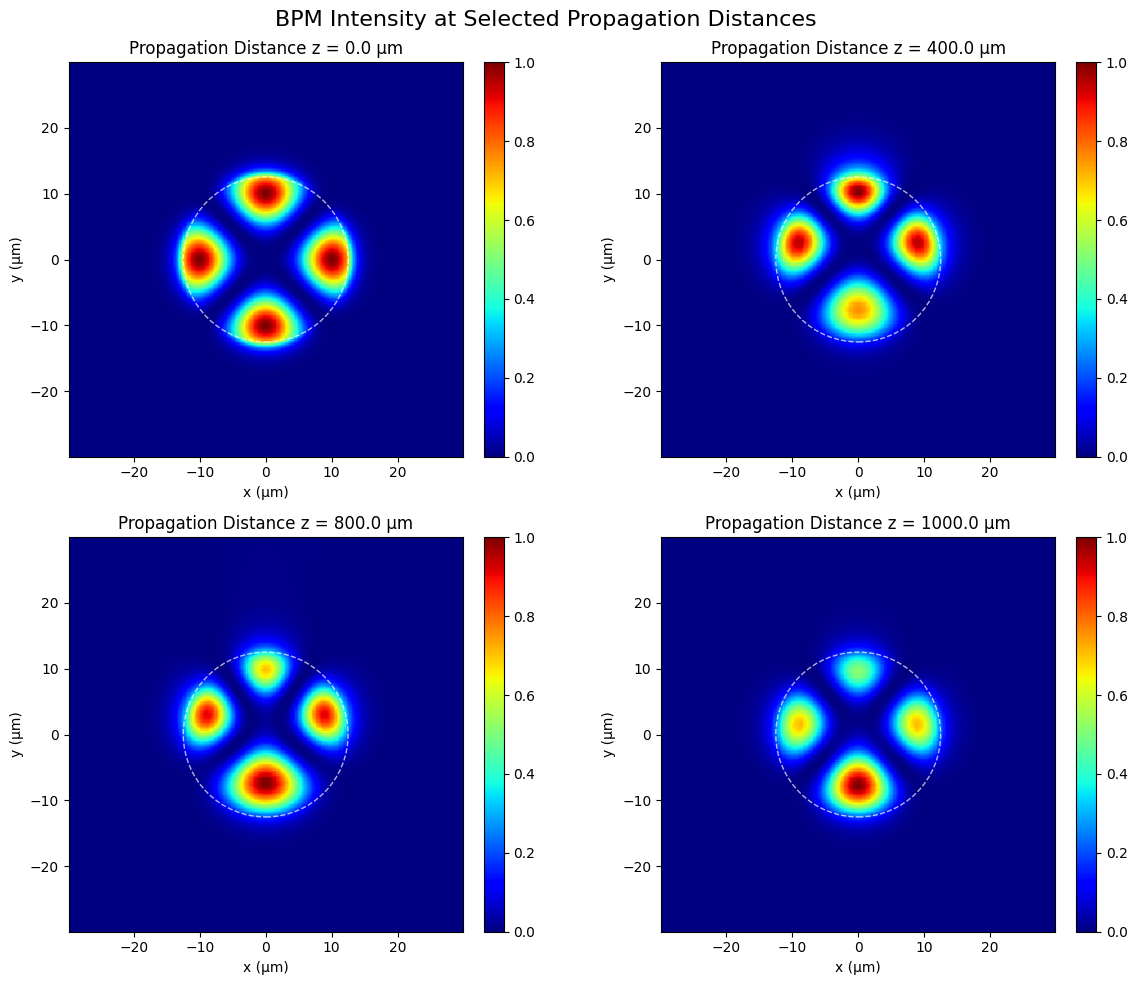

In [51]:
# --- plot
# 1. DEFINE THE ZOOM WINDOW
zoom_half_width = 30.0  # micrometers

# Figure out how many pixels this zoom window covers
zoom_pixels = int(2 * zoom_half_width / dx)

# 2. FIND THE CENTER OF THE GRID AND CROP
center_idx = Nx // 2
half_zoom = zoom_pixels // 2

crop_start = center_idx - half_zoom
crop_end = center_idx + half_zoom

# If the zoom window has an odd number of points, we need to take one
if zoom_pixels % 2 == 1:
    crop_end += 1

# Create the slice object for cropping
zoom_slice = slice(crop_start, crop_end)

# The x and y coordinates for our new zoomed-in view
zoomed_coords = x0[zoom_slice]

# 3. SET UP THE FIGURE (2 rows, 2 columns for the 4 saved z-positions)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("BPM Intensity at Selected Propagation Distances", fontsize=16)

# 4. LOOP THROUGH THE SAVED FIELDS AND PLOT
for axis, (distance_z, full_field) in zip(axes.flat, bpm_results.items()):
    
    # Cut out just the zoomed region from the full 2D field
    zoomed_field = full_field[zoom_slice, zoom_slice]

    intensity = np.abs(zoomed_field) ** 2
    
    # Normalize each frame independently.
    intensity = intensity / intensity.max()
    
    # Plot using pcolormesh. This automatically respects the correct
    image_plot = axis.pcolormesh(
        zoomed_coords, zoomed_coords, intensity,
        cmap='jet', shading='auto', vmin=0, vmax=1
    )
    
    # Draw a white dashed circle to mark the exact boundary of the fiber core
    core_circle = plt.Circle(
        (0, 0), core_radius,
        edgecolor='white', facecolor='none', linestyle='--', alpha=0.7
    )
    axis.add_patch(core_circle)
    
    # Labels and titles
    axis.set_title(f"Propagation Distance z = {distance_z:.1f} µm")
    axis.set_aspect('equal')  # This ensures the core appears as a perfect circle
    axis.set_xlabel("x (µm)")
    axis.set_ylabel("y (µm)")
    
    # Add a colorbar for each subplot
    fig.colorbar(image_plot, ax=axis, fraction=0.046, pad=0.04)

# Remove gaps between the subplots and display
plt.tight_layout()
plt.show()